## MULTIPLE LINEAR REGRESSION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import statsmodels.api as sm

####  1. LOAD DATASET

In [2]:
data = pd.read_csv("ToyotaCorolla - MLR.csv")

print("First 5 Rows")
print(data.head())

print("\nDataset Shape")
print(data.shape)

print("\nDataset Information")
print(data.info())

print("\nMissing Values")
print(data.isnull().sum())

print("\nSummary Statistics")
print(data.describe())

First 5 Rows
   Price  Age_08_04     KM Fuel_Type  HP  Automatic    cc  Doors  Cylinders  \
0  13500         23  46986    Diesel  90          0  2000      3          4   
1  13750         23  72937    Diesel  90          0  2000      3          4   
2  13950         24  41711    Diesel  90          0  2000      3          4   
3  14950         26  48000    Diesel  90          0  2000      3          4   
4  13750         30  38500    Diesel  90          0  2000      3          4   

   Gears  Weight  
0      5    1165  
1      5    1165  
2      5    1165  
3      5    1165  
4      5    1170  

Dataset Shape
(1436, 11)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP   

#### 2. EXPLORATORY DATA ANALYSIS

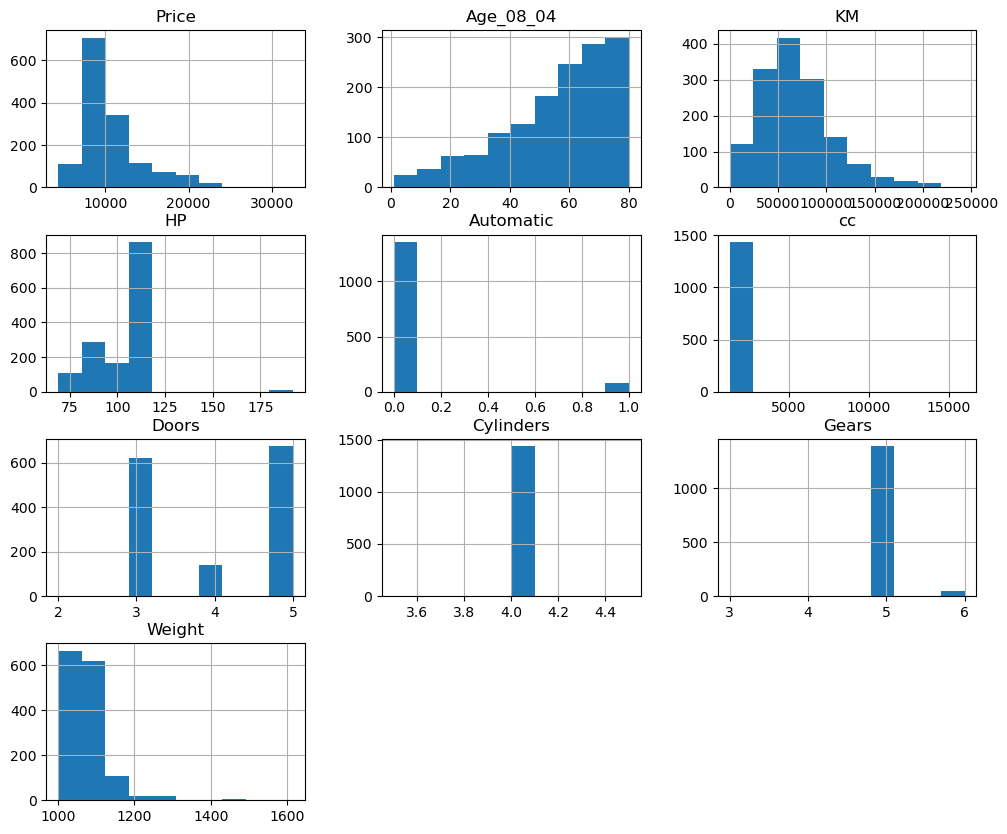

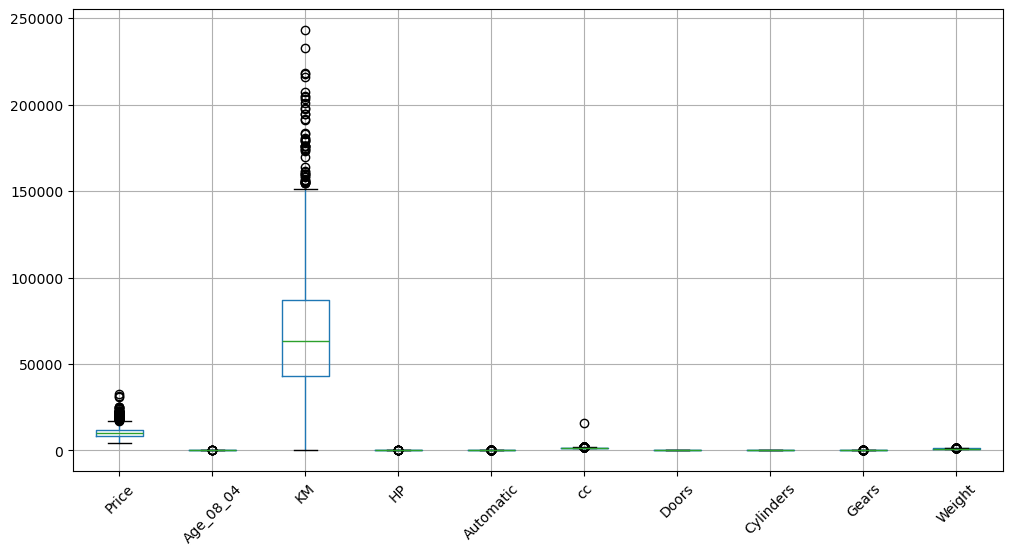

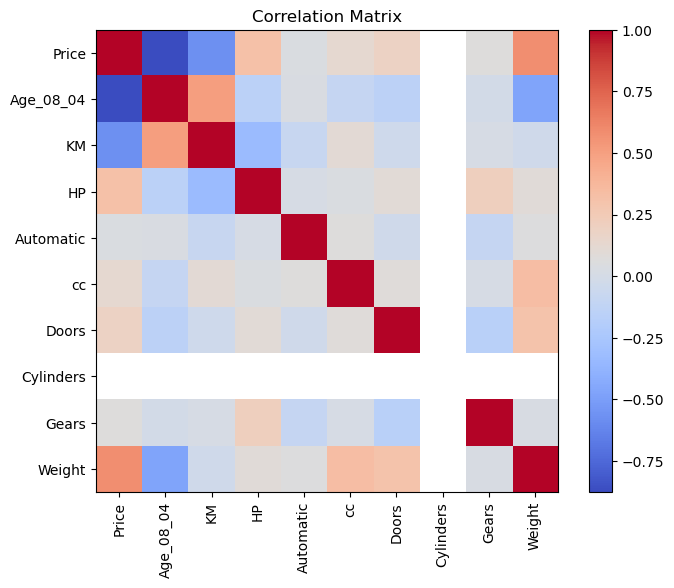

In [3]:
data.hist(figsize=(12,10))
plt.show()

data.boxplot(figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

corr = data.corr(numeric_only=True)

plt.figure(figsize=(8,6))
plt.imshow(corr,cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)
plt.yticks(range(len(corr.columns)),corr.columns)
plt.title("Correlation Matrix")
plt.show()

#### 3. DATA PREPROCESSING

In [4]:
encoder = LabelEncoder()
data["Fuel_Type"] = encoder.fit_transform(data["Fuel_Type"])

X = data.drop("Price",axis=1)
y = data["Price"]

#### 4. TRAIN TEST SPLIT

In [5]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Shape :",X_train.shape)
print("Testing Shape :",X_test.shape)


Training Shape : (1148, 10)
Testing Shape : (288, 10)


#### 5. FEATURE SCALING

In [6]:
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

##### MODEL 1 : ALL FEATURES

In [7]:
print("\nMODEL 1")

model1=LinearRegression()

model1.fit(X_train,y_train)

prediction1=model1.predict(X_test)

print("MAE :",mean_absolute_error(y_test,prediction1))
print("MSE :",mean_squared_error(y_test,prediction1))
print("RMSE :",np.sqrt(mean_squared_error(y_test,prediction1)))
print("R2 Score :",r2_score(y_test,prediction1))

print("\nCoefficients")

coef=pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model1.coef_
})

print(coef)


MODEL 1
MAE : 992.8982858371439
MSE : 2096851.1400177074
RMSE : 1448.0508071258091
R2 Score : 0.8428476112018

Coefficients
     Feature   Coefficient
0  Age_08_04 -1.214362e+02
1         KM -1.693560e-02
2  Fuel_Type  8.620564e+02
3         HP  2.065828e+01
4  Automatic  2.451969e+02
5         cc -7.351539e-02
6      Doors -3.627965e+01
7  Cylinders -6.821210e-13
8      Gears  5.302820e+02
9     Weight  2.351064e+01


##### MODEL 2 : IMPORTANT FEATURES

In [8]:
print("\nMODEL 2")

X2=data.drop(["Price","Doors","Cylinders"],axis=1)

y2=data["Price"]

X2_train,X2_test,y2_train,y2_test=train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=42
)

model2=LinearRegression()

model2.fit(X2_train,y2_train)

prediction2=model2.predict(X2_test)

print("MAE :",mean_absolute_error(y2_test,prediction2))
print("MSE :",mean_squared_error(y2_test,prediction2))
print("RMSE :",np.sqrt(mean_squared_error(y2_test,prediction2)))
print("R2 Score :",r2_score(y2_test,prediction2))


MODEL 2
MAE : 996.5852989065776
MSE : 2095592.563357349
RMSE : 1447.6161657557395
R2 Score : 0.8429419375585385


##### MODEL 3 : OLS MODEL

In [9]:
print("\nMODEL 3")

X3=data[[
    "Age_08_04",
    "KM",
    "HP",
    "Weight",
    "Fuel_Type"
]]

y3=data["Price"]

X3_train,X3_test,y3_train,y3_test=train_test_split(
    X3,
    y3,
    test_size=0.20,
    random_state=42
)

model3=LinearRegression()

model3.fit(X3_train,y3_train)

prediction3=model3.predict(X3_test)

print("MAE :",mean_absolute_error(y3_test,prediction3))
print("MSE :",mean_squared_error(y3_test,prediction3))
print("RMSE :",np.sqrt(mean_squared_error(y3_test,prediction3)))
print("R2 Score :",r2_score(y3_test,prediction3))


MODEL 3
MAE : 1001.1856801704598
MSE : 2125521.2239735955
RMSE : 1457.9167410979255
R2 Score : 0.8406988787072869


#### STATSMODELS SUMMARY

In [10]:
print("\nMODEL 3 SUMMARY")

X3_sm=sm.add_constant(X3)

result=sm.OLS(y3,X3_sm).fit()

print(result.summary())


MODEL 3 SUMMARY
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.863
Method:                 Least Squares   F-statistic:                     1809.
Date:                Mon, 29 Jun 2026   Prob (F-statistic):               0.00
Time:                        23:05:59   Log-Likelihood:                -12377.
No. Observations:                1436   AIC:                         2.477e+04
Df Residuals:                    1430   BIC:                         2.480e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -7069.7483   1176.517   

#### RIDGE REGRESSION

In [11]:
print("\nRIDGE REGRESSION")

ridge=Ridge(alpha=1.0)

ridge.fit(X_train_scaled,y_train)

ridge_prediction=ridge.predict(X_test_scaled)

print("MAE :",mean_absolute_error(y_test,ridge_prediction))
print("MSE :",mean_squared_error(y_test,ridge_prediction))
print("RMSE :",np.sqrt(mean_squared_error(y_test,ridge_prediction)))
print("R2 Score :",r2_score(y_test,ridge_prediction))


RIDGE REGRESSION
MAE : 992.8659873100587
MSE : 2096174.2541189406
RMSE : 1447.8170651428793
R2 Score : 0.8428983416680238


####  LASSO REGRESSION

In [12]:
print("\nLASSO REGRESSION")

lasso=Lasso(alpha=0.1)

lasso.fit(X_train_scaled,y_train)

lasso_prediction=lasso.predict(X_test_scaled)

print("MAE :",mean_absolute_error(y_test,lasso_prediction))
print("MSE :",mean_squared_error(y_test,lasso_prediction))
print("RMSE :",np.sqrt(mean_squared_error(y_test,lasso_prediction)))
print("R2 Score :",r2_score(y_test,lasso_prediction))


LASSO REGRESSION
MAE : 992.9095852338592
MSE : 2096720.8747663768
RMSE : 1448.0058269103674
R2 Score : 0.8428573741721097


## Interview Questions

#### 1.What is Normalization & Standardization and how is it helpful?

In [ ]:
Normalization : Normalization is a technique used to scale data into a fixed range, usually between 0 and 1.

In [ ]:
Formula : [
           \text{Normalized Value} = \frac{X - X_{min}}{X_{max} - X_{min}}
        ] 

In [ ]:
Standardization : Standardization is a technique used to transform data so that it has a mean of 0 and a standard deviation of 1.

In [ ]:
Formula : [
           Z = \frac{X - \mu}{\sigma}
         ]

In [ ]:
helpful
They bring all features to a similar scale.
They improve the performance of machine learning models.
They prevent features with large values from dominating the model.
Standardization is especially useful for Ridge and Lasso Regression.

#### 2.What techniques can be used to address multicollinearity in multiple linear regression?

In [ ]:
Multicollinearity occurs when two or more independent variables are highly correlated with each other. 
    
The following techniques can be used to reduce multicollinearity:
    
Remove highly correlated features.
Check the Variance Inflation Factor (VIF) and remove variables with high VIF values.
Use Ridge Regression, which reduces the effect of multicollinearity through L2 regularization.
Use Lasso Regression, which performs feature selection by reducing less important coefficients to zero.
Apply feature selection techniques or Principal Component Analysis (PCA) if necessary.